# 한글 형태소 분석, Wordcloud 시각화
- https://wikidocs.net/127851
- 예제 : https://wikidocs.net/172882

### 설치 라이브러리
- pip install wordcloud
- pip install konlpy

#### java 다운로드 설치하기(Konlpy 실행을 위해 필요함)
https://www.oracle.com/java/technologies/javase/jdk23-archive-downloads.html
- 다운로드 받아서 기본 설치
- 시스템 환경변수에 JAVA_HOME 정의 및 path 설정 : %JAVA_HOME%/bin

### font 파일 다운로드
- curl -L -O https://github.com/byungjooyoo/Dataset/raw/main/NanumGothic.ttf
### 이미지 다운로드
- curl -L -O https://github.com/byungjooyoo/Dataset/raw/main/korea_map.png
- curl -L -O https://raw.githubusercontent.com/byungjooyoo/Dataset/main/heart.png

In [ ]:
# Komoran은 Java 기반 형태소 분석기이므로 Java가 필요합니다. 아래 명령은 Ubuntu/Linux에서 최초 한 번만 실행합니다.
# java -version이 정상 출력된다면 다시 설치하지 않습니다.
#sudo apt update
#sudo apt install openjdk-17-jdk -y

In [ ]:
# 프로젝트 폴더에 한글 폰트와 워드클라우드 마스크 이미지를 저장하는 준비 명령입니다.
# 현재 fonts와 images 폴더에 세 파일이 있다면 다시 실행할 필요가 없습니다.
# mkdir -p fonts images
#이걸 해서 폴더 두개를 만들고
# 나눔고딕 글꼴 다운로드 : 
#curl -L \
#  https://github.com/byungjooyoo/Dataset/raw/main/NanumGothic.ttf \
#  -o fonts/NanumGothic.ttf

#대한민국 지도 이미지 다운로드
#curl -L \
#  https://github.com/byungjooyoo/Dataset/raw/main/korea_map.png \
#  -o images/korea_map.png

#하트 이미지 다운로드
#curl -L \
#  https://raw.githubusercontent.com/byungjooyoo/Dataset/main/heart.png \
#  -o images/heart.png

## 라이브러리 로딩

In [1]:
# wordcloud는 단어 시각화, konlpy는 한국어 형태소 분석에 사용합니다.
# 아래 설치 명령은 터미널에서 최초 한 번만 실행합니다.
# uv add wordcloud konlpy

In [2]:
# 실습에 필요한 클래스와 데이터를 불러옵니다.
from wordcloud import WordCloud  # 단어 빈도를 글자 크기로 표현하는 워드클라우드 생성 클래스
from konlpy.tag import Komoran   # 한국어 형태소 분석과 품사 판별을 수행하는 분석기
from konlpy.corpus import kolaw  # KoNLPy가 제공하는 대한민국 법률 문서 말뭉치
import matplotlib.pyplot as plt  # 생성된 워드클라우드 이미지를 화면에 표시

## 대상 텍스트(말뭉치) 다운로드
- https://konlpy.org/ko/latest/index.html
- https://konlpy.org/ko/latest/data/

In [3]:
# fileids()로 kolaw 말뭉치에 포함된 파일 이름 목록을 확인합니다.
kolaw.fileids()

['constitution.txt']

In [4]:
# open()으로 헌법 파일을 열고 read()로 전체 내용을 하나의 문자열로 읽습니다.
para = kolaw.open('constitution.txt').read()
print(type(para))  # str이면 문자열로 정상적으로 읽힌 것입니다.
para[:500]  # 전체 대신 앞의 500글자만 확인합니다.

<class 'str'>


'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의 사명에 입각하여 정의·인도와 동포애로써 민족의 단결을 공고히 하고, 모든 사회적 폐습과 불의를 타파하며, 자율과 조화를 바탕으로 자유민주적 기본질서를 더욱 확고히 하여 정치·경제·사회·문화의 모든 영역에 있어서 각인의 기회를 균등히 하고, 능력을 최고도로 발휘하게 하며, 자유와 권리에 따르는 책임과 의무를 완수하게 하여, 안으로는 국민생활의 균등한 향상을 기하고 밖으로는 항구적인 세계평화와 인류공영에 이바지함으로써 우리들과 우리들의 자손의 안전과 자유와 행복을 영원히 확보할 것을 다짐하면서 1948년 7월 12일에 제정되고 8차에 걸쳐 개정된 헌법을 이제 국회의 의결을 거쳐 국민투표에 의하여 개정한다.\n\n       제1장 총강\n  제1조 ① 대한민국은 민주공화국이다.\n②대한민국의 주권은 국민에게 있고, '

## 형태소 분석
- 형태소란? 언어학에서 일정한 의미를 가진 가장 작은 말의 단위를 말합니다. 다시 말해, 더 이상 쪼개면 의미가 없어지는 말의 조각

In [5]:
# Komoran 객체를 생성합니다. 이 시점에 Java 가상 머신(JVM)이 필요합니다.
tagger = Komoran()
# morphs(): 모든 형태소, pos(): (형태소, 품사) 쌍, nouns(): 명사만 반환합니다.
# 워드클라우드에는 글의 핵심 주제를 잘 보여 주는 명사만 사용합니다.
nouns = tagger.nouns(para)



In [7]:
# <!-- JVMNotFoundException: No JVM shared library file (libjvm.so) found. Try setting up the JAVA_HOME environment variable properly. -->
# [문제해결]  
# - java 설치 
#   sudo apt update
#   sudo apt install openjdk-17-jdk -y
# - java 설치위치 확인
#   readlink -f $(which java)
#   => 예) /usr/lib/jvm/java-17-openjdk-amd64/bin/java
# - JAVA_HOME 설정
#   nano ~/.bashrc
#   - 아래 코드 추가하기(저장 ctrl + o, 종료 ctrl + x)
#     export JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64
#     export PATH=$JAVA_HOME/bin:$PATH
# - 현재 shell에 적용하기
#   - source ~/.bashrc
# vs-code 종료하고, 다시 열기

In [6]:
# nouns는 추출한 명사들이 순서대로 담긴 Python 리스트입니다.
print(type(nouns))
nouns[:10]  # 전체 대신 앞의 명사 10개만 확인합니다.

<class 'list'>


['대한민국', '헌법', '역사', '전통', '국민', '운동', '건립', '대한민국', '임시', '정부']

## 문자열 타입으로 변환하기
- 워드클라우드에 넣기 위해서는 문자열타입으로 변환

In [7]:
# WordCloud.generate()는 문자열을 입력받으므로 명사 리스트를 하나의 문자열로 합칩니다.
# join()은 리스트의 원소 사이에 ', '를 넣어 연결합니다.
text = ", ".join(nouns)
text[:10]  # 변환 결과의 앞부분만 확인합니다.

'대한민국, 헌법, '

## 워드 클라우드 그리기

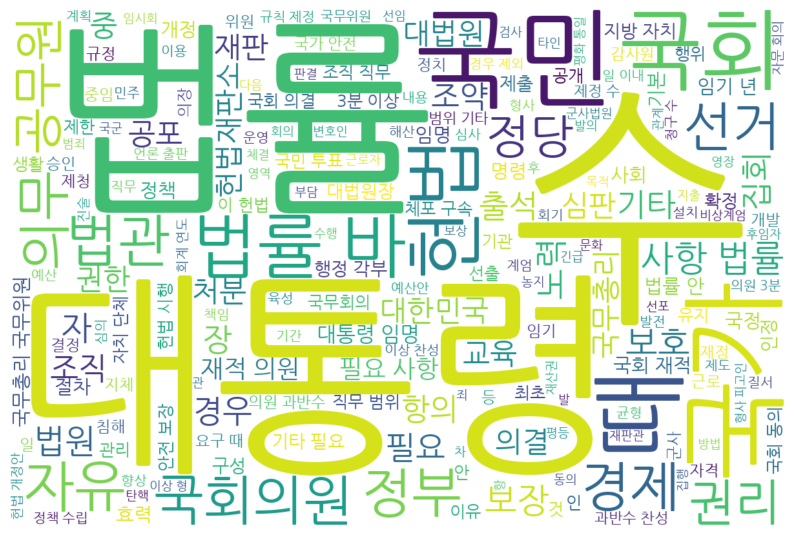

In [9]:
# 한글이 깨지지 않도록 다운로드한 나눔고딕 폰트 경로를 지정합니다.
my_path='./fonts/NanumGothic.ttf'
# 워드클라우드를 표시할 matplotlib 그림 영역의 크기를 인치 단위로 지정합니다.
fig = plt.figure(figsize=(10,10))

# background_color는 배경색, width와 height는 생성할 이미지의 픽셀 크기입니다.
# generate(text)는 문자열에서 단어 빈도를 계산해 자주 나온 단어를 더 크게 배치합니다.
wordcloud = WordCloud(font_path=my_path, 
                      background_color='white', 
                      width=1200, 
                      height=800).generate(text)
# imshow()로 이미지를 표시합니다. bilinear는 확대할 때 픽셀 경계를 부드럽게 보간합니다.
# WordCloud 객체는 배열처럼 변환될 수 있어 imshow()에 바로 전달할 수 있습니다.
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 이미지 시각화에는 좌표축이 필요 없으므로 숨깁니다.
plt.show()

## 이미지 모양으로 워드 클라우드 그리기

### 마스킹 하기

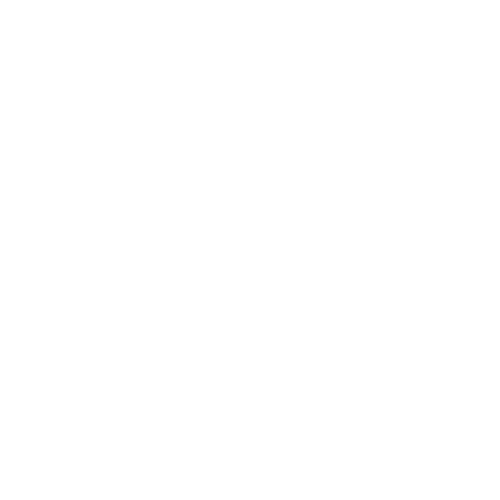

In [10]:
# NumPy는 이미지를 숫자 배열로 변환하고, PIL의 Image는 이미지 파일을 읽고 가공합니다.
import numpy as np
from PIL import Image

# 대한민국 지도 이미지를 열고 투명도 채널이 포함된 RGBA 형식으로 변환합니다.
icon = Image.open('./images/korea_map.png').convert("RGBA")
# 원본 이미지와 같은 크기의 흰색 RGB 배경을 만듭니다. RGB에서 255는 흰색, 0은 검정색입니다.
mask = Image.new("RGB", icon.size, (255,255,255))
mask

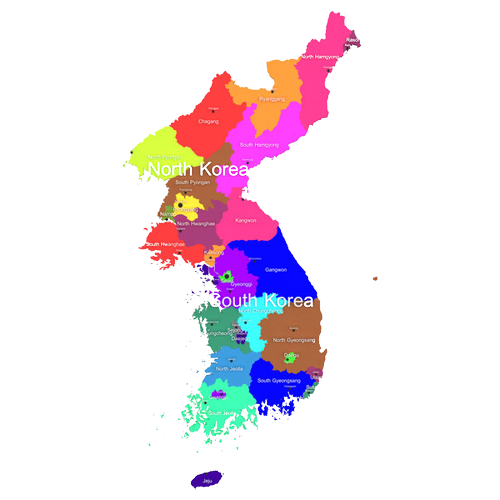

In [11]:
# icon 자체의 투명도 영역을 마스크로 사용해 흰 배경 위에 대한민국 지도 모양만 붙입니다.
mask.paste(icon, icon)
mask  # 만들어진 마스크 이미지를 확인합니다.

In [12]:
# WordCloud의 mask 옵션에 전달할 수 있도록 PIL 이미지를 NumPy 배열로 변환합니다.
mask = np.array(mask)
mask.shape  # (높이, 너비, 색상 채널 수) 형태로 배열 크기를 확인합니다.

(500, 500, 3)

### 워드클라우드 그리기

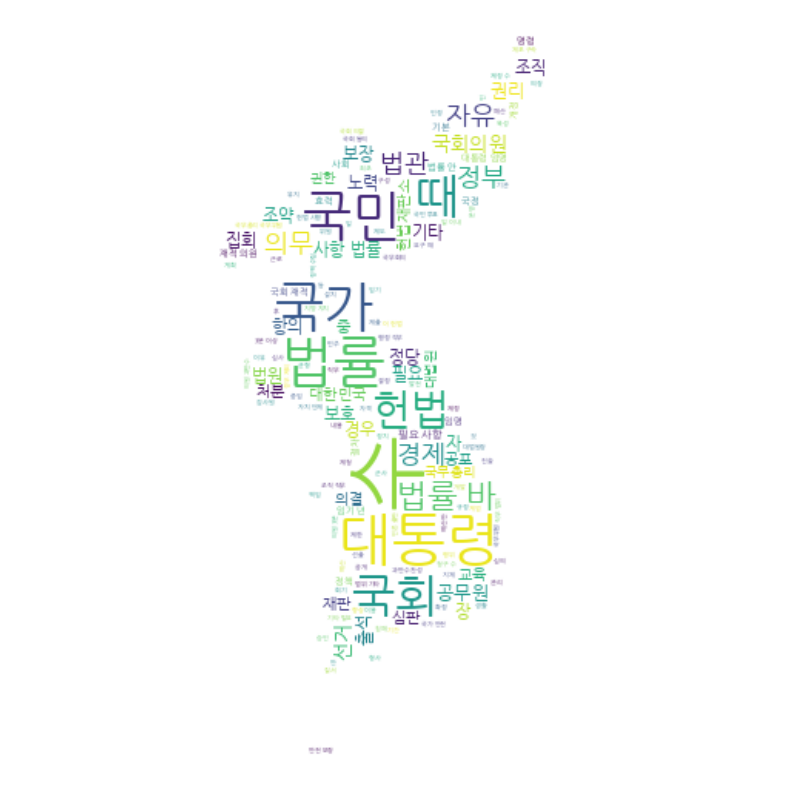

In [13]:
# 대한민국 지도 이미지를 흰 배경에 붙여 WordCloud용 마스크 배열을 다시 만듭니다.
from PIL import Image
icon = Image.open('./images/korea_map.png').convert("RGBA")
mask = Image.new("RGB", icon.size, (255,255,255))
mask.paste(icon,icon)
mask = np.array(mask)
# mask를 지정하면 단어들이 사각형 전체가 아니라 대한민국 지도 모양 안에 배치됩니다.
wordcloud = WordCloud(font_path=my_path,
                      # background_color=None,
                      background_color='white',
                      width=1200,
                      height=800,
                      mask=mask).generate(text)
fig = plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### 워드클라우드 그리기

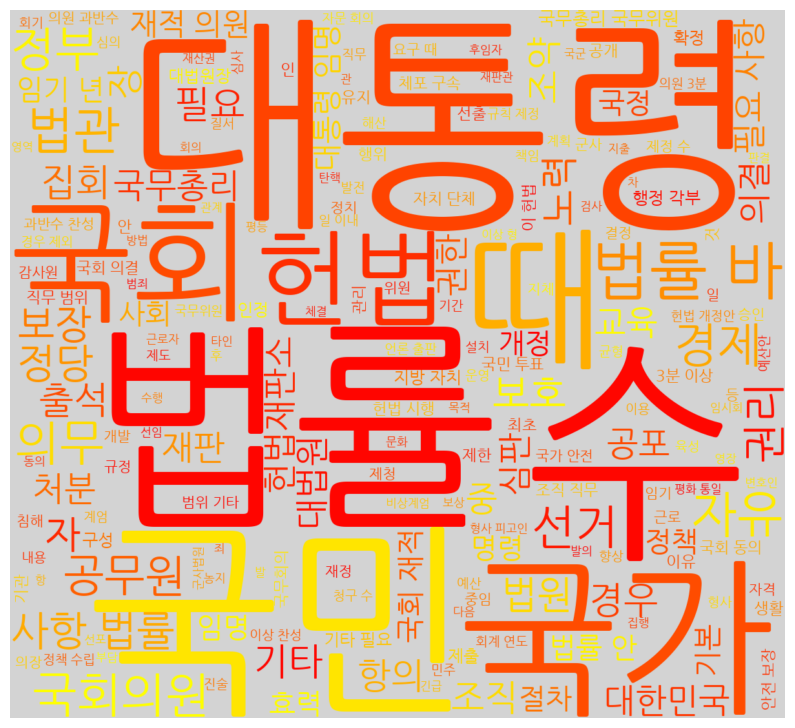

In [14]:
# 이번에는 하트 이미지를 사용해 다른 형태의 마스크를 만듭니다.
from PIL import Image
icon = Image.open('./images/heart.png').convert("RGBA")
mask = Image.new("RGB", icon.size, (255,255,255))
# paste(icon)은 하트 이미지를 흰 배경 위에 붙입니다.
mask.paste(icon)
mask = np.array(mask)
wordcloud = WordCloud(font_path=my_path,
                      background_color='lightgray',
                      width=1200,
                      height=800,
                      colormap='autumn',  # 단어 색상을 가을 계열 색상표에서 선택합니다.
                     mask=mask).generate(text)
fig = plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [15]:
# 현재 wordcloud 객체를 PNG 파일로 저장합니다. 상대경로이므로 프로젝트 폴더에 생성됩니다.
wordcloud.to_file("test.png")

# 다른 데이터로 해보기
## Korpora 데이터 활용
- 공식문서 사용방법 :  https://ko-nlp.github.io/Korpora/ko-docs/introduction/installation.html
- 데이터 문서 : https://github.com/ko-nlp/Korpora

In [16]:
# 다른 말뭉치로 같은 분석을 반복하기 위해 필요한 도구를 다시 불러옵니다.
# 앞부분부터 실행했다면 이미 로딩되어 있어 재사용할 수 있습니다.
from wordcloud import WordCloud
from konlpy.tag import Komoran
import matplotlib.pyplot as plt
from konlpy.corpus import kolaw

## 데이터 준비

In [ ]:
# Korpora는 한국어 말뭉치를 쉽게 내려받고 불러오는 라이브러리입니다.
# 설치되어 있지 않을 때만 터미널에서 아래 명령을 실행합니다.
# uv add Korpora

In [17]:
# Korpora를 불러오고 한국어 문장 의미 유사도 데이터셋인 korsts를 내려받습니다.
# fetch()는 네트워크를 사용하며 이미 받은 자료는 다시 다운로드하지 않을 수 있습니다.
from Korpora import Korpora
Korpora.fetch("korsts")

/home/aiuser/data_analisys_ex/.venv/lib/python3.12/site-packages/Korpora/korpus_open_subtitles.py:68: SyntaxWarning: invalid escape sequence '\S'
  pattern = re.compile('<seg>[\S ]+</seg>')
[korsts] download sts-train.tsv: 1.05MB [00:00, 15.2MB/s]
[korsts] download sts-dev.tsv: 311kB [00:00, 5.04MB/s]
[korsts] download sts-test.tsv: 254kB [00:00, 4.50MB/s]


In [18]:
# 다운로드된 korsts 데이터를 메모리로 불러와 corpus 변수에 저장합니다.
from Korpora import Korpora
corpus = Korpora.load("korsts")


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : KakaoBrain
    Repository : https://github.com/kakaobrain/KorNLUDatasets
    References :
        - Ham, J., Choe, Y. J., Park, K., Choi, I., & Soh, H. (2020). KorNLI and KorSTS: New Benchmark
           Datasets for Korean Natural Language Understanding. arXiv preprint arXiv:2004.03289.
           (https://arxiv.org/abs/2004.03289)

    This is the dataset repository for our paper
    "KorNLI and KorSTS: New Benchmark Datasets for Korean Natural Language Understanding."
    (https://arxiv.org/abs/2004.03289)
    We introduce KorNLI and KorSTS, which are NLI and STS datasets in Korean.

    # License
    Creative Commons Attribution-ShareAlike license (CC BY-SA 4.0)
    Details in https://creativecommons.org/licenses

## 형태소 추출

In [19]:
# corpus.train에서 훈련용 데이터 묶음을 가져오고 texts 속성에서 문장 목록만 추출합니다.
train_texts = corpus.train
train_texts = train_texts.texts

# Komoran이 분석할 수 있도록 문장 리스트를 공백으로 연결한 하나의 문자열로 만듭니다.
text_corpus = " ".join(train_texts)
print(type(text_corpus))  # str인지 확인합니다.
text_corpus[:200]  # 전체 대신 앞의 200글자만 확인합니다.

<class 'str'>


'비행기가 이륙하고 있다. 한 남자가 큰 플루트를 연주하고 있다. 한 남자가 피자에 치즈를 뿌려놓고 있다. 세 남자가 체스를 하고 있다. 한 남자가 첼로를 연주하고 있다. 몇몇 남자들이 싸우고 있다. 남자가 담배를 피우고 있다. 남자가 피아노를 치고 있다. 한 남자가 기타를 치고 노래를 부르고 있다. 사람이 고양이를 천장에 던지고 있다. 그 남자는 다른 남자'

In [20]:
# 긴 말뭉치 전체를 분석하므로 환경에 따라 몇 분이 걸릴 수 있습니다.
tagger = Komoran()
nouns = tagger.nouns(text_corpus)  # 전체 문장에서 명사만 리스트로 추출합니다.

## 문자열로 만들기

In [21]:
# 추출한 명사 리스트를 ', '로 연결해 WordCloud가 받을 문자열로 변환합니다.
text2 = ", ".join(nouns)
text2[:20]  # 변환 결과의 앞부분을 확인합니다.

'비행기, 이륙, 남자, 플루트, 연주'

## 워드클라우드 그리기

(np.float64(-0.5), np.float64(1199.5), np.float64(799.5), np.float64(-0.5))

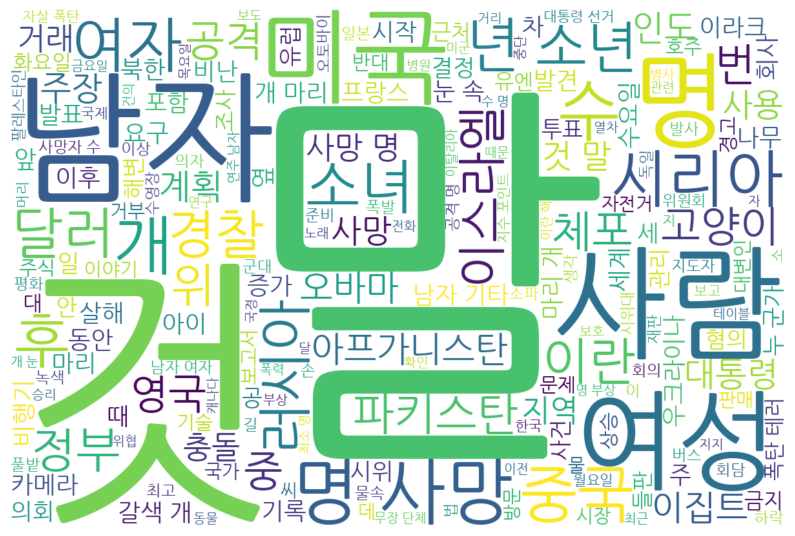

In [22]:
# 나눔고딕 폰트를 지정하고 Korpora 말뭉치의 명사로 워드클라우드를 생성합니다.
my_path='./fonts/NanumGothic.ttf'
wordcloud = WordCloud(font_path=my_path, 
                      background_color='white', 
                      width=1200, 
                      height=800).generate(text2)
fig = plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 이미지에 불필요한 x축과 y축을 숨깁니다.
plt.show()  # 완성된 워드클라우드를 화면에 출력합니다.